In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"illeeman","key":"15ebfe0736b50b462c139b40106f3a76"}'}

In [ ]:
# Create kaggle folder and copy the file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Now download the skin disease dataset
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d skin_data

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [01:01<00:00, 90.4MB/s]



In [ ]:
#check if metadat exists
!ls skin_data/HAM10000_metadata.csv

skin_data/HAM10000_metadata.csv


In [ ]:
# Check how many images are there (should be around 10,000+)
!ls skin_data/HAM10000_images_part_1 | wc -l
!ls skin_data/HAM10000_images_part_2 | wc -l

5000
5015


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the metadata file
df = pd.read_csv('/content/skin_data/HAM10000_metadata.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDisease Classes and Count:")
print(df['dx'].value_counts())

Dataset Shape: (10015, 7)

First 5 rows:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

Disease Classes and Count:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


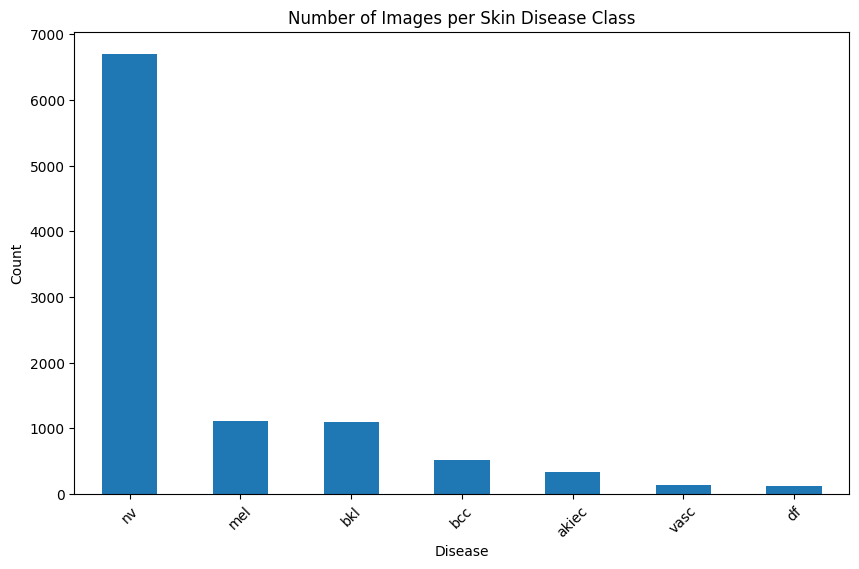


Class Names Explanation:
['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


In [ ]:
# Plot the number of images per disease
plt.figure(figsize=(10,6))
df['dx'].value_counts().plot(kind='bar')
plt.title('Number of Images per Skin Disease Class')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print("\nClass Names Explanation:")
print(df['dx'].unique())

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print("✅ Imports successful")

✅ Imports successful


In [ ]:
df = pd.read_csv('/content/skin_data/HAM10000_metadata.csv')

def get_image_path(img_id):
    path1 = f'/content/skin_data/HAM10000_images_part_1/{img_id}.jpg'
    path2 = f'/content/skin_data/HAM10000_images_part_2/{img_id}.jpg'
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None   # safety

df['image_path'] = df['image_id'].apply(get_image_path)

# Remove any bad rows (if any)
df = df.dropna(subset=['image_path'])
#label ncoding to numerical values from text
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
class_names = le.classes_

print("✅ Data prepared")
print("Total valid images:", len(df))

✅ Data prepared
Total valid images: 10015


In [ ]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

print(f"Train: {len(train_df)} images")
print(f"Validation: {len(val_df)} images")

Train: 8012 images
Validation: 2003 images


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

#normalization and augmentation of training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

#normalization of validation set
val_datagen = ImageDataGenerator(rescale=1./255)

#tabular data actually becoming input for CNN : df -> batches of images -> feed into CNN
train_generator = train_datagen.flow_from_dataframe(#Reads image paths from your DataFrame
#Loads images from disk
#Resizes them
#Applies augmentation (train only)
#Converts labels to numeric vectors
#Yields data in batches

    dataframe=train_df,
    x_col='image_path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42                # ← add this
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='dx',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42                # ← add this
)

Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get classes in exact same order as generator
class_indices = train_generator.class_indices
# looks like: {'akiec':0, 'bcc':1, 'bkl':2, 'df':3, 'mel':4, 'nv':5, 'vasc':6}

#Fixing imbalance data
classes_ordered = list(class_indices.keys())

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(classes_ordered),
    y=train_df['dx']        # ← use 'dx' not 'label'
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(4.368593238822246), 1: np.float64(2.7848453249913105), 2: np.float64(1.3021290427433772), 3: np.float64(12.440993788819876), 4: np.float64(1.2860353130016051), 5: np.float64(0.21338020666879728), 6: np.float64(10.040100250626567)}


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),  # ← fixed
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,727 (24.87 MB)

 Trainable params: 6,518,279 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('skin_model_best.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

# Train the model with fewer epochs for testing
print("🚀 Starting training with 10 epochs... (This should take 8-20 minutes)")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,                    # ← Reduced to 10
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training Completed!")

# Quick final accuracy
final_train_acc = history.history['accuracy'][-1] * 100
final_val_acc = history.history['val_accuracy'][-1] * 100

print(f"Final Training Accuracy   : {final_train_acc:.2f}%")
print(f"Final Validation Accuracy : {final_val_acc:.2f}%")

🚀 Starting training with 10 epochs... (This should take 8-20 minutes)
Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.3534 - loss: 3.1260
Epoch 1: val_accuracy improved from None to 0.01398, saving model to skin_model_best.h5



Epoch 1: finished saving model to skin_model_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 100s 368ms/step - accuracy: 0.3867 - loss: 2.5084 - val_accuracy: 0.0140 - val_loss: 6.7342
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.4637 - loss: 1.6322
Epoch 2: val_accuracy improved from 0.01398 to 0.42137, saving model to skin_model_best.h5



Epoch 2: finished saving model to skin_model_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 348ms/step - accuracy: 0.4549 - loss: 1.6334 - val_accuracy: 0.4214 - val_loss: 1.6482
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.5097 - loss: 1.4764
Epoch 3: val_accuracy improved from 0.42137 to 0.55167, saving model to skin_model_best.h5



Epoch 3: finished saving model to skin_model_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 89s 354ms/step - accuracy: 0.5109 - loss: 1.4416 - val_accuracy: 0.5517 - val_loss: 1.1726
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.5305 - loss: 1.3559
Epoch 4: val_accuracy improved from 0.55167 to 0.58462, saving model to skin_model_best.h5



Epoch 4: finished saving model to skin_model_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 349ms/step - accuracy: 0.5197 - loss: 1.4151 - val_accuracy: 0.5846 - val_loss: 1.1175
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.5258 - loss: 1.4130
Epoch 5: val_accuracy did not improve from 0.58462
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 351ms/step - accuracy: 0.5130 - loss: 1.4114 - val_accuracy: 0.5522 - val_loss: 1.1777
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.5393 - loss: 1.2269
Epoch 6: val_accuracy did not improve from 0.58462
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 351ms/step - accuracy: 0.5313 - loss: 1.2786 - val_accuracy: 0.5537 - val_loss: 1.1202
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.5504 - loss: 1.3121
Epoch 7: val_accuracy improved from 0.58462 to 0.61458, saving model to skin_model_best.h5



Epoch 7: finished saving model to skin_model_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 350ms/step - accuracy: 0.5344 - loss: 1.2914 - val_accuracy: 0.6146 - val_loss: 0.9526
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.5594 - loss: 1.1328
Epoch 8: val_accuracy did not improve from 0.61458
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 346ms/step - accuracy: 0.5533 - loss: 1.1892 - val_accuracy: 0.5612 - val_loss: 1.1462
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.5378 - loss: 1.2189
Epoch 9: val_accuracy did not improve from 0.61458
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 350ms/step - accuracy: 0.5423 - loss: 1.2089 - val_accuracy: 0.5627 - val_loss: 1.1031
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.5598 - loss: 1.1796
Epoch 10: val_accuracy did not improve from 0.61458
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 350ms/step - accuracy: 0.5675 - loss: 1.1795 - val_accuracy: 0.5786 - val_loss: 1.0653
Restoring model weights from the end of the bes

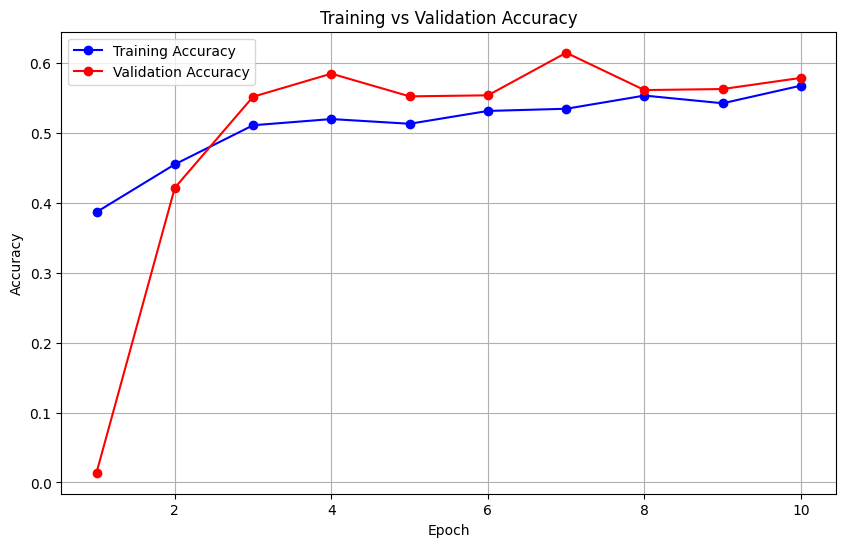

Graph saved as accuracy_graph.png


In [ ]:
import matplotlib.pyplot as plt

# Get the data from training history
epochs = range(1, len(history.history['accuracy']) + 1)

# Plot the graph
plt.figure(figsize=(10, 6))

plt.plot(epochs, history.history['accuracy'], 'b-o', label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'r-o', label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Save it as image file
plt.savefig('accuracy_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print("Graph saved as accuracy_graph.png")

In [ ]:
# Save the model (already doing this with ModelCheckpoint)
# But run this too just to be safe
model.save('skin_model_best.h5')
print("Model saved!")

# Save the training history (so you keep your graph data)
import pickle
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("History saved!")

# Download both to your PC
from google.colab import files
files.download('skin_model_best.h5')
files.download('training_history.pkl')
files.download('accuracy_graph.png')
print("All files downloaded!")

Model saved!
History saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!


In [ ]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# Load model
model = load_model('skin_model_best.h5', compile=False)

# Compile it fresh
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Save in keras format instead
model.save('skin_model_compatible.keras')

print("Done!")

from google.colab import files
files.download('skin_model_compatible.keras')

Done!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()
# Select your skin_model_best.h5 from your PC when dialog opens

Saving skin_model_best.h5 to skin_model_best (1).h5


In [ ]:
import tensorflow as tf
import keras
print("TF version:", tf.__version__)
print("Keras version:", keras.__version__)

TF version: 2.19.0
Keras version: 3.13.2


In [ ]:
!pip install tf2onnx==1.16.1

INFO: pip is looking at multiple versions of onnx to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 19.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: onnx
    Found existing installation: onnx 1.21.0
    Uninstalling onnx-1.21.0:
      Successfully uninstalled onnx-1.21.0
  Attempting uninstall: tf2onnx
    Found existing installation: tf2onnx 1.17.0
    Uninstalling tf2onnx-1.17.0:
      Successfully uninstalled tf2onnx-1.17.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follo

In [ ]:
import tensorflow as tf
import tf2onnx
import numpy as np

# Load model
model = tf.keras.models.load_model('skin_model_best.h5', compile=False)

# Convert using input signature method
input_signature = [tf.TensorSpec(shape=[None, 128, 128, 3], dtype=tf.float32)]

onnx_model, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=input_signature,
    opset=13
)

# Save
with open("skin_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Conversion successful!")

from google.colab import files
files.download('skin_model.onnx')

AttributeError: 'Sequential' object has no attribute 'output_names'